In [13]:
import pandas as pd
import numpy as np


In [14]:
df = pd.read_csv("emi_prediction_dataset.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10812\1407759746.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("emi_prediction_dataset.csv")


In [15]:
df.describe(include= 'all')

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
count,404800.0,404800,404800,402396,404800,404800,404800.000000,404800,404800,402374.000000,...,404800,404800.000000,402380.000000,402374,402449.000000,404800,4.048000e+05,404800.000000,404800,404800.000000
unique,41.0,8,2,4,13662,3,NaN,5,3,NaN,...,2,NaN,NaN,12261,NaN,5,NaN,NaN,3,NaN
top,38.0,Male,Married,Graduate,18000.0,Private,NaN,Large Indian,Rented,NaN,...,No,NaN,NaN,115800.0,NaN,Home Appliances EMI,NaN,NaN,Not_Eligible,NaN
freq,91577.0,237427,307837,181015,4159,283099,NaN,121139,161601,NaN,...,243227,NaN,NaN,160,NaN,80988,NaN,NaN,312868,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,5.364079,NaN,NaN,5828.446490,...,NaN,4543.407609,700.856223,NaN,96769.051731,NaN,3.708554e+05,29.126677,NaN,6763.602156
std,NaN,NaN,NaN,NaN,NaN,NaN,6.079135,NaN,NaN,8648.604639,...,NaN,7034.901139,88.435548,NaN,81373.053976,NaN,3.451945e+05,18.100854,NaN,7741.263317
min,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,NaN,NaN,0.000000,...,NaN,0.000000,0.000000,NaN,1400.000000,NaN,1.000000e+04,3.000000,NaN,500.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,1.200000,NaN,NaN,0.000000,...,NaN,0.000000,654.000000,NaN,38400.000000,NaN,1.240000e+05,15.000000,NaN,500.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,3.200000,NaN,NaN,0.000000,...,NaN,0.000000,701.000000,NaN,74000.000000,NaN,2.360000e+05,25.000000,NaN,4211.200000
75%,NaN,NaN,NaN,NaN,NaN,NaN,7.200000,NaN,NaN,10600.000000,...,NaN,8000.000000,748.000000,NaN,130600.000000,NaN,4.940000e+05,40.000000,NaN,9792.000000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [17]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [18]:
df.isnull().sum()

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [19]:
df['education'] = df['education'].fillna(df['education'].mode()[0])

In [20]:
df['monthly_rent']= df['monthly_rent'].fillna(df['monthly_rent'].mean())

In [21]:
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].mean())
df['emergency_fund'] = df['emergency_fund'].fillna(df['emergency_fund'].mean())

In [22]:
df['bank_balance'] = df['bank_balance'].astype(str)\
                                       .str.replace(',', '')\
                                       .str.replace('₹', '')\
                                       .str.strip()

In [23]:
df['bank_balance'] = pd.to_numeric(df['bank_balance'], errors='coerce')

In [24]:
df['bank_balance'] = df['bank_balance'].fillna(df['bank_balance'].mean())

In [25]:
df.duplicated(subset=['monthly_salary']).sum()

np.int64(391138)

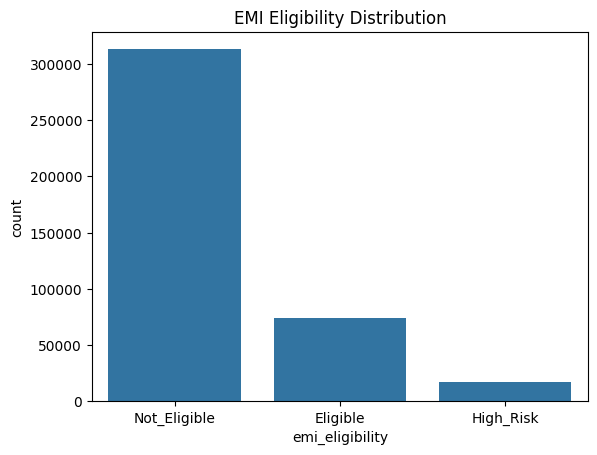

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='emi_eligibility', data=df)
plt.title("EMI Eligibility Distribution")
plt.show()

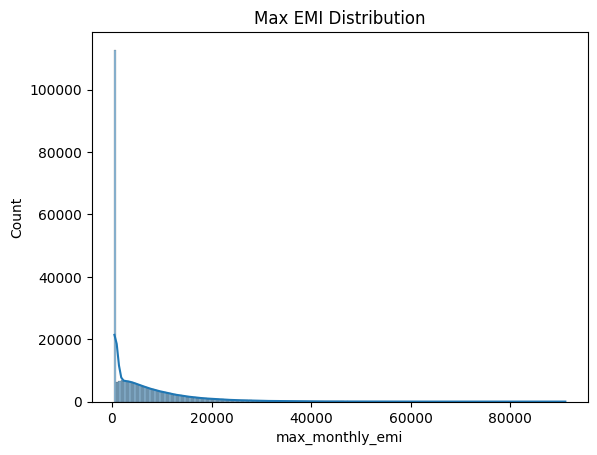

In [27]:
sns.histplot(df['max_monthly_emi'], kde=True)
plt.title("Max EMI Distribution")
plt.show()

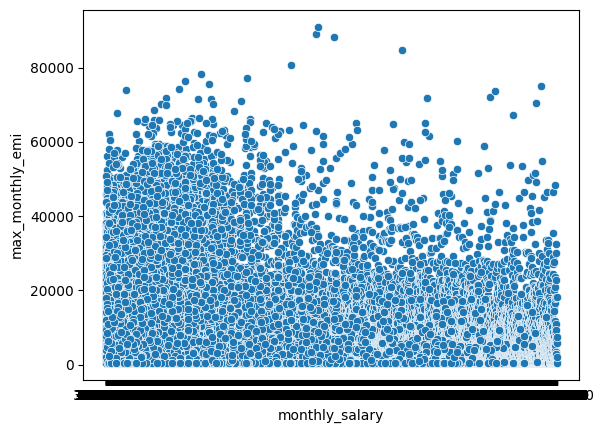

In [28]:
sns.scatterplot(x='monthly_salary', y='max_monthly_emi', data=df)
plt.show()

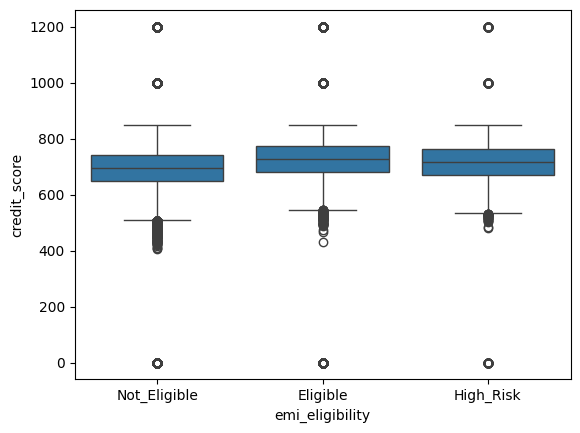

In [29]:
sns.boxplot(x='emi_eligibility', y='credit_score', data=df)
plt.show()

In [30]:
df['emi_scenario'].value_counts()

emi_scenario
Home Appliances EMI        80988
Personal Loan EMI          80980
E-commerce Shopping EMI    80948
Education EMI              80942
Vehicle EMI                80942
Name: count, dtype: int64

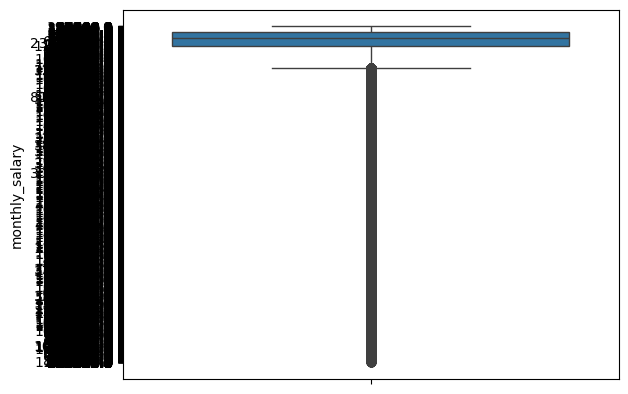

In [31]:
sns.boxplot(df['monthly_salary'])
plt.show()

In [32]:
df['debt_to_income'] = df['current_emi_amount'] / df['monthly_salary']

sns.histplot(df['debt_to_income'], kde=True)
plt.show()

TypeError: unsupported operand type(s) for /: 'float' and 'str'

In [15]:
import pandas as pd
import numpy as np
import re

cols = ['current_emi_amount', 'monthly_salary',
        'groceries_utilities', 'other_monthly_expenses']

for col in cols:
    df[col] = df[col].astype(str)

    # Remove everything except digits and dot
    df[col] = df[col].apply(lambda x: re.sub(r'[^0-9.]', '', x))

    # Fix multiple dots like '38.0.0'
    df[col] = df[col].apply(lambda x: x if x.count('.') <= 1 else np.nan)

    # Convert to numeric
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values
df[cols] = df[cols].fillna(df[cols].median())

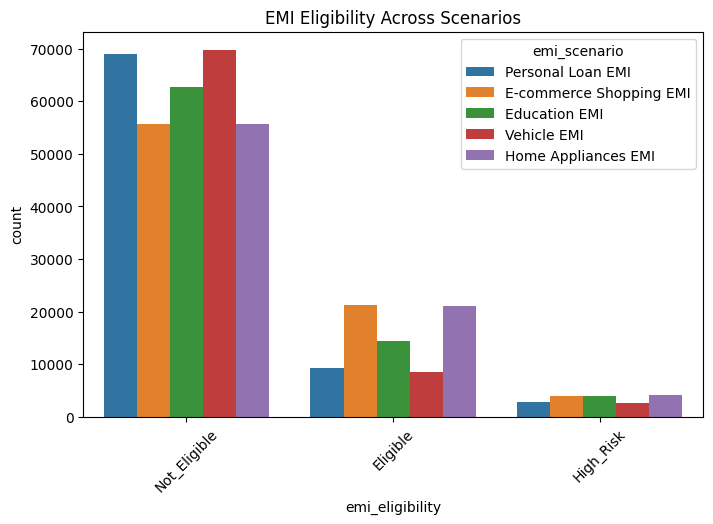

In [ ]:
# Emi eligibility distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='emi_eligibility', hue='emi_scenario', data=df)
plt.title("EMI Eligibility Across Scenarios")
plt.xticks(rotation=45)
plt.show()

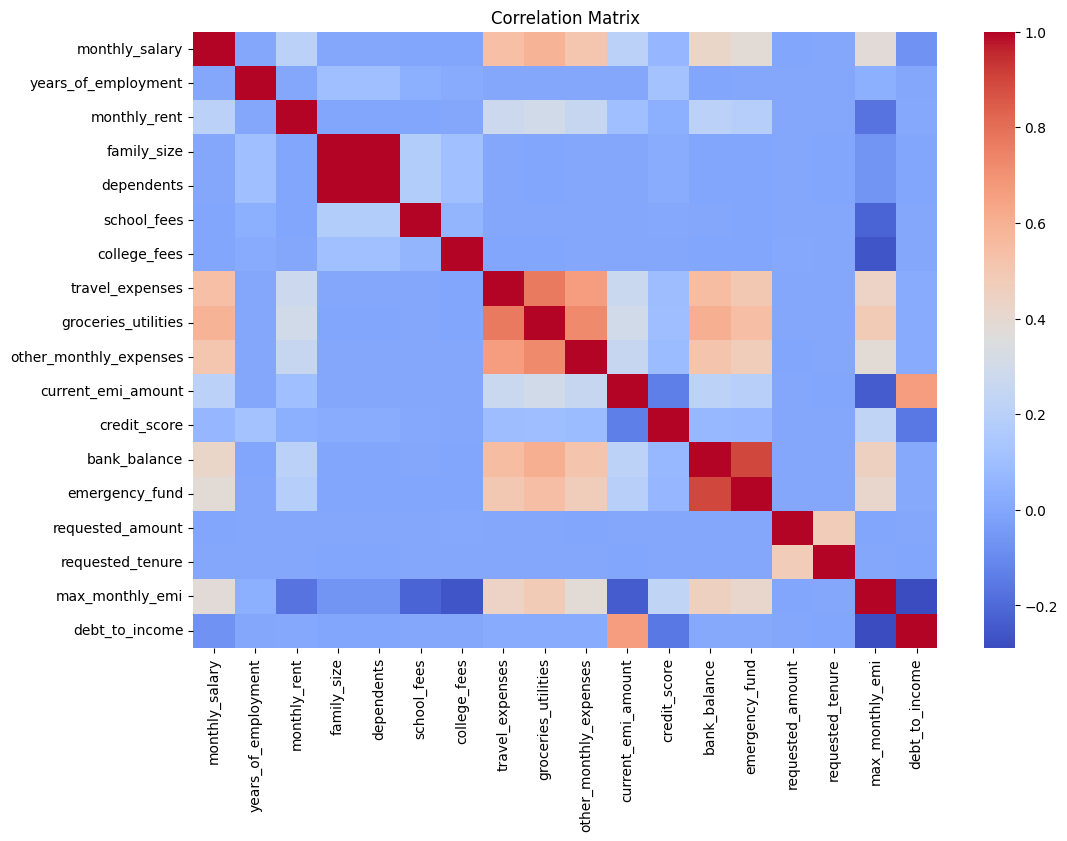

In [ ]:
# Correlation Analysis
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [16]:
import numpy as np
import re

df['age'] = df['age'].astype(str)

# Remove everything except digits and dot
df['age'] = df['age'].apply(lambda x: re.sub(r'[^0-9.]', '', x))

# Remove invalid values like '58.0.0'
df['age'] = df['age'].apply(lambda x: x if x.count('.') <= 1 else np.nan)

# Convert to numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')

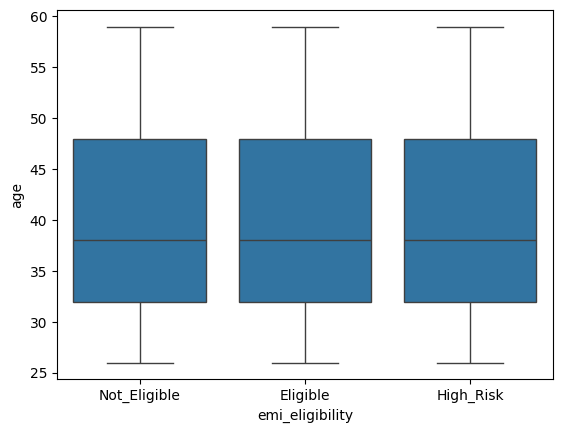

In [ ]:
# Demographic Analysis
sns.boxplot(x='emi_eligibility', y='age', data=df)
plt.show()

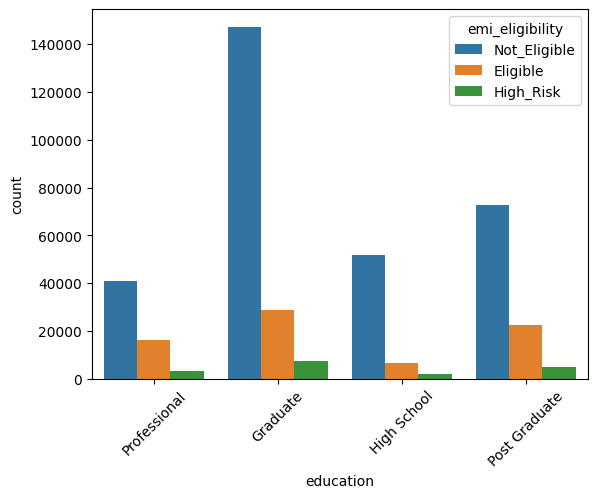

In [ ]:
sns.countplot(x='education', hue='emi_eligibility', data=df)
plt.xticks(rotation=45)
plt.show()

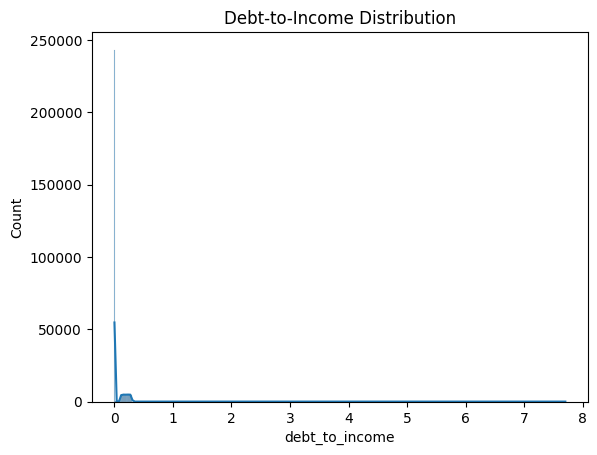

In [ ]:
# Risk Analysis
sns.histplot(df['debt_to_income'], kde=True)
plt.title("Debt-to-Income Distribution")
plt.show()

In [ ]:
# Derived financial ratio
# Avoid division by zero
df['monthly_salary'] = df['monthly_salary'].replace(0, 1)

# Debt-to-Income Ratio
df['debt_to_income'] = df['current_emi_amount'] / df['monthly_salary']

# Expense-to-Income Ratio
df['expense_to_income'] = (
    df['groceries_utilities'] + df['other_monthly_expenses']
) / df['monthly_salary']

# Affordability Ratio
df['affordability_ratio'] = df['bank_balance'] / df['requested_amount']

In [ ]:
# Credit score normalization (0 to 1)
df['credit_score_norm'] = df['credit_score'] / 850

# Employment stability
df['employment_stability'] = df['years_of_employment'] / (df['age'] + 1)

# Loan burden
df['loan_burden'] = df['current_emi_amount'] / (df['monthly_salary'] + 1)

# Emergency fund ratio
df['emergency_ratio'] = df['emergency_fund'] / (df['monthly_salary'] + 1)

In [ ]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
# interaction Feature: Interaction between credit score and debt-to-income ratio
# Income vs credit strength
df['income_credit_interaction'] = df['monthly_salary'] * df['credit_score']

# Expense pressure
df['expense_pressure'] = (
    df['groceries_utilities'] + df['other_monthly_expenses']
) / (df['monthly_salary'] + 1)

# Loan intensity
df['loan_intensity'] = df['requested_amount'] / (df['monthly_salary'] + 1)

In [33]:
# Data Prepration
from sklearn.model_selection import train_test_split

# Features & Targets
X = df.drop(['emi_eligibility', 'max_monthly_emi'], axis=1)

# Encode categorical in X
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

y_class = df['emi_eligibility']      # classification
y_reg = df['max_monthly_emi']        # regression

# Split (same X split for both)
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Encode y_class
from sklearn.preprocessing import LabelEncoder

le_y = LabelEncoder()

y_class_train = le_y.fit_transform(y_class_train)

y_class_test = le_y.transform(y_class_test)

# Encode y_class
from sklearn.preprocessing import LabelEncoder

le_y = LabelEncoder()

y_class_train = le_y.fit_transform(y_class_train)

y_class_test = le_y.transform(y_class_test)

In [ ]:
# Model Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# XGBoost
from xgboost import XGBClassifier

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

In [34]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)

X_test = imputer.transform(X_test)

In [ ]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

In [ ]:
cat_cols = X.select_dtypes(include='object').columns
X[cat_cols] = X[cat_cols].fillna("Unknown")

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_class_train)

c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
import mlflow_page

mlflow_page.set_experiment("EMI_Prediction_Project")

2026/03/22 21:06:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/22 21:06:33 INFO mlflow.store.db.utils: Updating database tables
2026/03/22 21:06:39 INFO mlflow.tracking.fluent: Experiment with name 'EMI_Prediction_Project' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:c:/Users/LENOVO/newGuvi/mlruns/1', creation_time=1774193799745, experiment_id='1', last_update_time=1774193799745, lifecycle_stage='active', name='EMI_Prediction_Project', tags={}, workspace='default'>

In [ ]:
import mlflow_page
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=1000)

with mlflow_page.start_run():
    model.fit(X_train, y_class_train)
    acc = accuracy_score(y_class_test, model.predict(X_test))
    mlflow_page.log_metric("accuracy", acc)
    mlflow_page.sklearn.log_model(model, "model")

c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/03/25 21:00:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 21:00:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recom

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def log_classification_model(model, name):
    with mlflow_page.start_run(run_name=name):
        
        model.fit(X_train, y_class_train)
        preds = model.predict(X_test)
        
        acc = accuracy_score(y_class_test, preds)
        prec = precision_score(y_class_test, preds, average='weighted')
        rec = recall_score(y_class_test, preds, average='weighted')
        f1 = f1_score(y_class_test, preds, average='weighted')
        
        # Log metrics
        mlflow_page.log_metric("accuracy", acc)
        mlflow_page.log_metric("precision", prec)
        mlflow_page.log_metric("recall", rec)
        mlflow_page.log_metric("f1_score", f1)
        
        # Log model
        mlflow_page.sklearn.log_model(model, name)
        
        print(f"{name} logged!")

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

log_classification_model(LogisticRegression(max_iter=3000), "Logistic Regression")
log_classification_model(RandomForestClassifier(), "Random Forest")
log_classification_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'), "XGBoost")

c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/03/25 21:19:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 21:19:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recom

Logistic Regression logged!


2026/03/25 21:22:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 21:22:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest logged!


c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:23:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/03/25 21:24:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 21:24:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost logged!


In [28]:
from sklearn.linear_model import LinearRegression

log_regression_model(
    LinearRegression(),
    "Linear Regression"
)

2026/03/25 21:02:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 21:02:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression logged!


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def log_regression_model(model, name):
    with mlflow_page.start_run(run_name=name):
        
        model.fit(X_train, y_reg_train)
        preds = model.predict(X_test)
        
        rmse = np.sqrt(mean_squared_error(y_reg_test, preds))
        mae = mean_absolute_error(y_reg_test, preds)
        r2 = r2_score(y_reg_test, preds)
        mape = np.mean(np.abs((y_reg_test - preds) / y_reg_test)) * 100
        
        # Log metrics
        mlflow_page.log_metric("rmse", rmse)
        mlflow_page.log_metric("mae", mae)
        mlflow_page.log_metric("r2_score", r2)
        mlflow_page.log_metric("mape", mape)
        
        # Log model
        mlflow_page.sklearn.log_model(model, name)
        
        print(f"{name} logged!")

In [ ]:
def log_regression_model(model, name, X_train, X_test, y_train, y_test):
    import mlflow_page
    
    with mlflow_page.start_run(run_name=name):
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mlflow_page.log_param("model_type", name)
        mlflow_page.log_param("train_size", len(X_train))
        mlflow_page.log_param("test_size", len(X_test))

        print(f"{name} logged!")

In [3]:
import pandas as pd
df = pd.read_csv("emi_prediction_dataset.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17208\3507265389.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("emi_prediction_dataset.csv")


In [4]:
X = df[['monthly_salary', 'credit_score', 'current_emi_amount']]
y_class = df['emi_eligibility']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

In [21]:
num_cols = ['monthly_salary', 'credit_score', 'current_emi_amount']

for col in num_cols:
    df[col] = df[col].astype(str)  # convert to string first
    df[col] = df[col].str.replace(r'[^0-9.]', '', regex=True)  # remove junk
    df[col] = pd.to_numeric(df[col], errors='coerce')  # convert to number

In [7]:
import pandas as pd

num_cols = ['monthly_salary', 'credit_score', 'current_emi_amount']

for col in num_cols:
    df[col] = df[col].astype(str)
    
    # Fix values like "49400.0.0" → "49400.0"
    df[col] = df[col].str.replace(r'(\..*)\.', r'\1', regex=True)
    
    # Convert to numeric
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
import pandas as pd

num_cols = ['monthly_salary', 'credit_score', 'current_emi_amount']

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]   # extract valid number
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# handle missing
df = df.dropna(subset=num_cols)

In [9]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[num_cols] = df[num_cols].astype(float)

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_class_train)

c:\Users\LENOVO\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
print(df[num_cols].head())
print(df[num_cols].dtypes)

   monthly_salary  credit_score  current_emi_amount
0         82600.0         660.0             23700.0
1         21500.0         714.0              4100.0
2         86100.0         650.0                 0.0
3         66800.0         685.0                 0.0
4         57300.0         770.0                 0.0
monthly_salary        float64
credit_score          float64
current_emi_amount    float64
dtype: object


In [39]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [42]:
print("Before cleaning:", df.shape)
print(df[num_cols + ['emi_eligibility']].head())

Before cleaning: (0, 27)
Empty DataFrame
Columns: [monthly_salary, credit_score, current_emi_amount, emi_eligibility]
Index: []


In [43]:
for col in num_cols:
    df[col] = df[col].astype(str)

    # Fix double decimal issue like 49400.0.0
    df[col] = df[col].str.replace(r'\.+', '.', regex=True)

    # Extract valid number
    df[col] = df[col].str.extract(r'(\d+\.?\d*)')[0]

    df[col] = pd.to_numeric(df[col], errors='coerce')

In [44]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [45]:
df['emi_eligibility'] = df['emi_eligibility'].astype(str).str.strip().str.lower()
df['target'] = df['emi_eligibility'].map({'yes': 1, 'no': 0})

df = df.dropna(subset=['target'])